# Web Scrapper Yahoo Finance

# Packages Downloaded

In [337]:
## Loading Packages

import pandas as pd
import numpy as np
import requests, lxml
from lxml import html
from datetime import datetime
import time
from bs4 import BeautifulSoup
import math 
import statistics
import seaborn as sns
import calendar


# Part 1: Web Scrapping Yahoo Finance

In [351]:


# A stable internet network is needed. 
#If theres a Nothing at Node Error wait a while and reload


# First determine the initial and end dates of data and then the total number of days 

# Split the dates into parts since we cannot scrape more than 100 rows

# Periods should divide the range such that each scrape contains <100 rows


# Please note that Yahoo finance doesn't include the end date. To include it add a day

# If the data doesnt give the last day 

# then the day may fall on a non trading day.

dates = pd.date_range(start="1927-12-29",end="2022-03-25", periods = 350 ).to_pydatetime().tolist()



## Define time object for url
def date_converter(x):
    # convert our datetime object 
    ans = str( int(time.mktime( x.timetuple()) ) )
    return ans




## Function to pull data for 100 rows of the table

def webscrape(time1,time2):
    
    ini = time1
    last = time2
    
    ## apply the date converter  functiion
    
    begin = date_converter(ini)
    end = date_converter(last)
    
    ## Define url for scraping 
    items = ("https://finance.yahoo.com/quote/%5EGSPC/history?period1=",begin,"&period2=",end,"&interval=1d&filter=history&frequency=1d&includeAdjustedClose=true")
    url = "".join(items)
    
    ## Pull the data from the website using beautiful soup package
    r = requests.get(url,headers={"User-Agent":"Mozilla/5.0"})
    soup = BeautifulSoup(r.text,'lxml')
    
    # Specifing the class to locate the data
    Table = soup.find('table', class_='W(100%) M(0)')
    
    # Pull out all rows in the class node for the table
    Rows = Table.find_all('tr', class_='BdT Bdc($seperatorColor) Ta(end) Fz(s) Whs(nw)')


    # Empty list is created to store the data
    fans = []

    # For each row we determine there should be 7 columns of data and log them in a 
    # dictionary
    
    for i in range(0, len(Rows)):
        # Empty dictionary to store data present in each row
        RowDict = {}
        
        # Extracted all the columns of a row and stored in a variable
        Values = Rows[i].find_all('td')
        
        if len(Values) == 7:
            RowDict["Date"] = Values[0].find('span').text.replace(',', '')
            RowDict["Open"] = Values[1].find('span').text.replace(',', '')
            RowDict["High"] = Values[2].find('span').text.replace(',', '')
            RowDict["Low"] = Values[3].find('span').text.replace(',', '')
            RowDict["Close"] = Values[4].find('span').text.replace(',', '')
            RowDict["Adj Close"] = Values[5].find('span').text.replace(',', '')
            
            #Note certain days dont report volume. Condition it to replace it with None 
            if getattr(Values[6].find('span'), 'text', None) is None:
                RowDict["Volume"] = getattr(Values[6].find('span'), 'text', None)
            else:
                RowDict["Volume"] = Values[6].find('span').text.replace(',', '')
    
        # Append the dictionary into the list then run next iteration
        fans.append(RowDict)
    
    
    fans = pd.DataFrame(fans)
    return(fans)
    





## Full Data Output:

# intitialise empty data frame
data = pd.DataFrame()

# Based on the date range given and partions we run a loop for each date  
# Scrape and join the results
for i in range(len(dates) - 1):
    time1 = dates[i]
    time2 = dates[i + 1]
    data = data.append(webscrape(time1,time2))

x = data.iloc[:,0]
data["Date"] = pd.to_datetime(x, format='%b %d %Y')
data = data.astype({'Open':'float','High':'float','Low':'float', 'Close':'float' , 'Adj Close':'float'})
data = data.sort_values(by='Date')


data



,Date,Open,High,Low,Close,Adj Close,Volume
66,1927-12-30,17.66,17.66,17.66,17.66,17.66,None
65,1928-01-03,17.76,17.76,17.76,17.76,17.76,None
64,1928-01-04,17.72,17.72,17.72,17.72,17.72,None
63,1928-01-05,17.55,17.55,17.55,17.55,17.55,None
62,1928-01-06,17.66,17.66,17.66,17.66,17.66,None
...,...,...,...,...,...,...,...
4,2022-03-18,4407.34,4465.40,4390.57,4463.12,4463.12,6681510000
3,2022-03-21,4462.40,4481.75,4424.30,4461.18,4461.18,3961050000
2,2022-03-22,4469.10,4522.00,4469.10,4511.61,4511.61,3962880000
1,2022-03-23,4493.10,4501.07,4455.81,4456.24,4456.24,4014360000


## Saving File to S&P 500 historical data.txt

In [352]:

#Save the file to a comma delimited text file
data.to_csv('/Users/johnmarkin/Downloads/Python for Finance/S&P 500 historical data.txt')

# Part 2:  Monthly Means 

Mean is calculated using arithmetic average 


In [353]:
# Structure the dataframe to required formats
data = data.astype({'Open':'float','High':'float','Low':'float', 'Close':'float' , 'Adj Close':'float'})

# Set the index of the data
data.set_index('Date', inplace=True)

In [356]:

# Create a copy of the data to avoid tampering 

data2 = data.copy()

# Create a new column Dates to help subsetting
data2["Dates"] = data2.index
data2["Dates"] = data2['Dates'].dt.strftime('%B %Y')

# Calculate the daily log returns

x = data2['Adj Close']
data2['Monthly_return'] = np.log(data2['Adj Close'] / data2['Adj Close'].shift(1))

# Calculate the monthly returns and group the returns based Month and Year
final =pd.DataFrame(data2.groupby(['Dates'] )['Monthly_return'].apply(statistics.mean) )
final["Month&Year"] = final.index
final.index = pd.to_datetime(final.index, format='%B %Y')
final["year"] = final.index.year
final = final.sort_values(by= 'year')
final = final[[ "Month&Year" , "Monthly_return"  ]]
final



,Month&Year,Monthly_return
Dates,,
1927-12-01,December 1927,NaN
1928-04-01,April 1928,0.001147
1928-09-01,September 1928,0.000677
1928-02-01,February 1928,-0.000937
1928-12-01,December 1928,0.000144
...,...,...
2021-05-01,May 2021,0.000274
2021-11-01,November 2021,-0.000399
2022-03-01,March 2022,0.001827


In [ ]:
## Saving File to Monthly Returns.txt

In [360]:
# Save the file to a comma delimited text file
final.to_csv('/Users/johnmarkin/Downloads/Python for Finance/Monthly Returns.txt', index = False)

# Part 3: Visualizations:

The plot shows that monthly returns  over the years are quite similar they range between (-0.005, 0.01). However, there are some outliers out of this range but the frequency of such points provide no substantial information in deciding the appropriate month. 
So ignoring outliers, October will be the most volatile month as the returns are more spaced indicating a higher volatility.




<AxesSubplot:xlabel='month', ylabel='Monthly_return'>

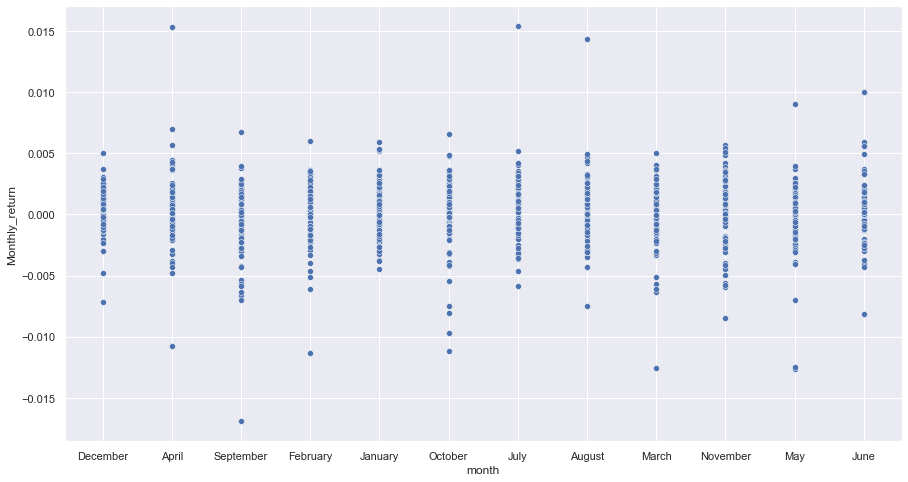

In [343]:

# Visualizing Volatile Month by Returns
final["month"] = pd.to_datetime(final.index)
final['month'] = final['month'].dt.month_name()

# plot scatter plot based on seaborn
sns.set(rc = {'figure.figsize':(15,8)})
sns.scatterplot(x = 'month' , y = 'Monthly_return', data = final)


Quantitatively, I will use the Standard Deviation to determine the most volatile month.
from the above plot we observe that the points are clustered around (-0.005, 0.01).
The higher  the standard deviation , the more the values for that month deviate from the mean. This will serve as useful basis to compare the other months. 

September reported the highest value: 0.002991

In [344]:

final2 = final.copy()

#Remove NaN
final2 = final2.iloc[1:,:]

# Calculate monthly returns and group the returns based on Month and Year


final2["Month&Year"] = final2.index

final2.index = pd.to_datetime(final2.index, format='%B %Y')

# create a column of the months

final2["month"] = final2.index.month
final2['month'] = final2['month'].apply(lambda x: calendar.month_name[x])

# Further calculate the standard deviation on the grouped identical months

final2 =pd.DataFrame(final2.groupby(['month'] )['Monthly_return'].apply(statistics.stdev) )

# Get the index of the maximum stdev
max_index = final2["Monthly_return"].idxmax()

#rename columns
final2  = final2.rename(columns = {'Monthly_return':'Monthly_stdev'})

#print final results
final2.loc[max_index]

Monthly_stdev    0.002991
Name: September, dtype: float64